# **Regularization Optimization**

## Assignment Number : 

- **Student Name**: Sanjay Pahari
- **Roll Number**: 42
- **Group**: Computer Engineering, 7th semester
- **Date**: 19 April 2026
- **Dataset Used**: BatteryDrainSysSim Dataset
- **Resource Utilized**: d2l.ai

## **Objective**
This assigment focuses on understanding and implementing regularization and optimization concept in MLP. Below are some objectives that this assingments would achieve:

1. Get understanding of following concepts: Dropout, L1/L2 rergularization, Optimizers (SGD, Adam Batch normalization experiments)
2. Do experiments on regularization comparing outputs when it is enabled and disabled.
3. Doing demostration on overfiting and anlayzing techniques that reduces overfitting and what can be the trade-offs of those

## **Theoretical Background**

Let's dive little deeper into Dropout, L1/L2 regularization, Optimizers: SGD and Adam Batch normalization experiments.

### **Dropout**

Dropout can simply be understood as technique of regularization where turning some neurons took place during training phase. 

![Fig: Dropout](../../assets/3/dropout.png)

Overfit can be overcome using Dropout. Initialization at the rate of 0.5 (50%) in a particular layer can drop about half of the neuron of that layer. Dropout is done in training sample while training. 

### **Regularization**

It is the technique in ML, where penalty is added to keep the model simple and avoid overfitting.

#### **Types of Regularization**

##### **1. Ridge (L2) Regression**

The main idea behind the ridge regression is to find a new line that doesn't fit perfectly to the training data (done using bias).

In return, the variance is reduced and also avoid overfitting.

![Fig: Ridge Regression](../../assets/3/ridge1.png)

It basically not only minimize the sum of the squared residuals (like Least Sqaure) but also minimize (Lambda \* Slope^2)

When sample size (training size) are relatively small, Ridge Regression (L2 regularization) can improve predictions made form new data (i.e. reduce variance) by making predicitons les sensitive to the training data by introducing penalty.

This is done by adding the ridge regression penalty((Lambda \* Slope^2)) to the thing that must be minimized. i.e. th
e sum of squared residuals (Least Sqaure) + (Lambda \* Slope^2)

Lambda is determined using cross validation method. (test with the test data). Greater lambda results asymtotically zero.

Main effect is that it makes the prediction size less sensitive to the tiny training dataset.

##### **2. Lasso (L1) Regression**

The main idea behind the lasso regression similar to the ridge regression but here there is absolute value of slope in the penalty not square.

Similar to the Ridge regression, In return, the variance is reduced and also avoid overfitting. And main effect is that it makes the prediction size less sensitive to the tiny training dataset.

![Fig: Lasso Regression](../../assets/3/lasso.png)

Lasso Regression can exclude useless varibles from equation due to the absolute value, it is little better than ridge regression at reducing teh variance in models that contains a lot of useless variables.

This is done by adding the lasso regression penalty((Lambda \* |Slope|)) to the thing that must be minimized. i.e. th
e sum of squared residuals (Least Sqaure) + (Lambda \* |Slope|)



## **Implementation**

So, let's built multi-layer perceptron and use our simulated data for battery percentage decay prediciton.
 
I will be desigining an MLP that can predict the battery drain pecentage after 15mins with input of a window of about 40 instance of features that are captured in 15 seconds interval.

In [2]:
# Initialization

import numpy as np # Numpy is used for tensor operations. Discussed in assignment 1.
import pandas as pd # library for data analysis & manipulation 
# Matplotlib is a library for creating static, animated and interactive visulatizations
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec # help to layout multiple axes

# scikit-learn is a library for simple an efficent tools for predictive data anlaysis and so on built on numpy,scipy and matplotlib
from sklearn.preprocessing import StandardScaler   # only for scaling but not for modelling
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # for calculation
from sklearn.model_selection import train_test_split # for splitting the data into training and testing sets

import random, os

import scipy.stats as stats # it provides algorithms for optimization, integration, interpolation, eigenvalue problems and so on

import seaborn as sns # used for creating statistical graphics

# Reporducibility
SEED = 66
np.random.seed(SEED)
random.seed(SEED)

# Plot Style
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

### **Step 1:** 

#### Dataset Load & EDA (Exploratory Data Analysis)

In [3]:
############################
#Load BatteryDrainSysSim Dataset
############################

path = os.path.join("../../dataset/battery_dataset/battery_dataset.csv")
dataset = pd.read_csv(path)

print(dataset.head())

    cpu_mean    cpu_std    cpu_min     cpu_max  freq_mean  freq_std  \
0  46.217808  11.489978  36.734128   62.341136   3.190880  0.311351   
1  86.550001   4.398656  80.127735  100.000000   2.046959  0.287137   
2  71.239576   6.506316  64.344188   83.187274   3.408988  0.207967   
3  61.906094  10.622648  54.196027   71.243775   3.233481  0.271946   
4  30.921305   8.267161  22.866505   40.704003   3.362051  0.214293   

   temp_mean  temp_std  active_load_mean  active_load_std  heavy_cpu_mean  \
0  62.699963  3.322932          0.205942         0.051645       24.705772   
1  87.346319  3.524870          0.247424         0.024373       38.456597   
2  80.351434  5.385782          0.065248         0.129122       43.206934   
3  80.578126  1.155303          0.198414         0.039079       19.701839   
4  47.896561  3.335180          0.100851         0.171904        9.094375   

   bg_load_mean  brightness_mean  download_mean    upload_mean  \
0     21.512036         0.851159  923534.967

In [4]:
############################
# Dataset Exploration
############################

print(dataset.describe().round(2).to_string())
print(f"\nNull values: {dataset.isnull().sum().sum()}")
print(f"Shape : {dataset.shape}")




       cpu_mean   cpu_std   cpu_min   cpu_max  freq_mean  freq_std  temp_mean  temp_std  active_load_mean  active_load_std  heavy_cpu_mean  bg_load_mean  brightness_mean  download_mean  upload_mean  drain_rate_mean  battery_drop_15min
count  20000.00  20000.00  20000.00  20000.00   20000.00  20000.00   20000.00  20000.00          20000.00         20000.00        20000.00      20000.00         20000.00       20000.00     20000.00         20000.00            20000.00
mean      54.95      8.49     42.47     67.30       2.65      0.28      68.48      3.51              0.28             0.10           24.74         30.21             0.60      505772.79    100983.83             3.63                5.38
std       20.20      3.74     20.62     20.39       0.49      0.13      14.43      1.44              0.13             0.06           12.42         13.97             0.23      284869.44     57428.19             1.14                1.28
min       20.00      2.00      5.00     25.16       1.80    

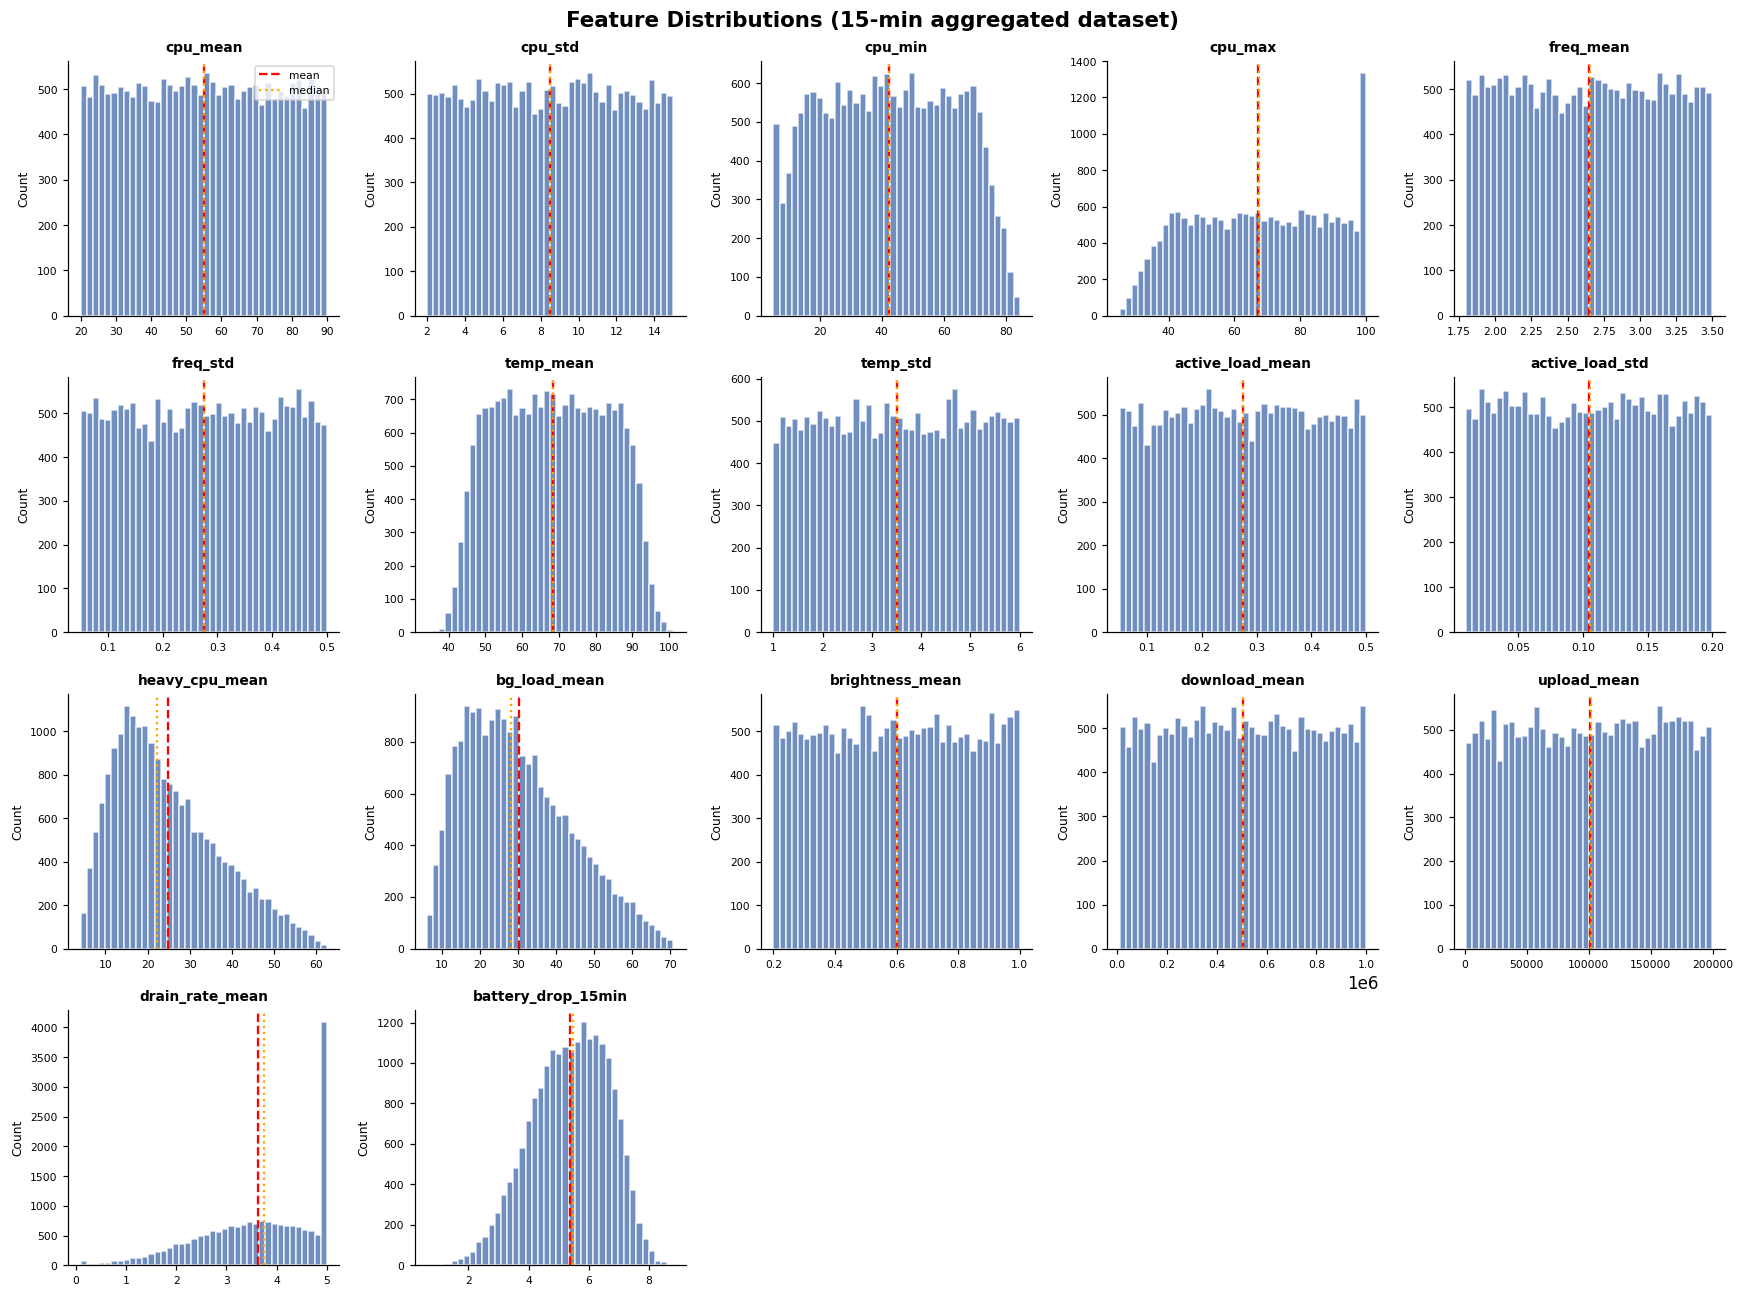

In [5]:
############################
# Feature Distributions & Battery Traces
############################
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
fig.suptitle("Feature Distributions (15-min aggregated dataset)", 
             fontsize=14, fontweight="bold")

feat_cols = [
    "cpu_mean","cpu_std","cpu_min","cpu_max",
    "freq_mean","freq_std",
    "temp_mean","temp_std",
    "active_load_mean","active_load_std",
    "heavy_cpu_mean","bg_load_mean",
    "brightness_mean","download_mean","upload_mean",
    "drain_rate_mean",
    "battery_drop_15min"
]

axes = axes.flatten()
for i, (ax, col) in enumerate(zip(axes, feat_cols)):
    ax.hist(dataset[col], bins=40, color="#4C72B0", alpha=0.8, edgecolor="white")
    ax.axvline(dataset[col].mean(), color='red', lw=1.5, linestyle='--', label='mean')
    ax.axvline(dataset[col].median(), color='orange', lw=1.5, linestyle=':', label='median')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(feat_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [6]:
############################
# Skewness & Kurtosis
############################
'''
Skewness measures the asymmetry of a distribution.
Kurtosis measures the peakedness of a distribution. 
'''
skew_df = pd.DataFrame({
    "Skewness" : dataset.skew(),
    "kurtosis" : dataset.kurtosis()
}).round(3)
skew_df['SkewFlag'] = skew_df["Skewness"].apply(
    lambda x: 
    "Highly Right Skewed (Long Right Tail)" if x > 1 else
    "Moderately Right Skewed (Little Long Right Tail)" if x > 0.5 else
    "Approximately Symmetric" if -0.5 <= x <= 0.5 else
    "Moderately Left Skewed (Little Long Left Tail)" if x < -0.5 and x >= -1 else
    "Highly Left Skewed (Long Left Tail)"
)
skew_df["KurtorsisFlag"] = skew_df["kurtosis"].apply(lambda x: 
    "Highly Leptokurtic (Sharp Peak)" if x > 1 else
    "Moderately Leptokurtic (Little Sharp Peak)" if x > 0.5 else
    "Approximately Mesokurtic(Near Normal Distribution Curve)" if -0.5 <= x <= 0.5 else
    "Moderately Platykurtic (Little Flat Peak)" if x < -0.5 and x >= -1 else
    "Highly Platykurtic (Flat Peak)"
)
print("\n Skewness & Kurtosis: ")
print(skew_df.to_string())


 Skewness & Kurtosis: 
                    Skewness  kurtosis                                          SkewFlag                                             KurtorsisFlag
cpu_mean               0.003    -1.194                           Approximately Symmetric                            Highly Platykurtic (Flat Peak)
cpu_std                0.001    -1.194                           Approximately Symmetric                            Highly Platykurtic (Flat Peak)
cpu_min                0.000    -1.107                           Approximately Symmetric                            Highly Platykurtic (Flat Peak)
cpu_max               -0.041    -1.159                           Approximately Symmetric                            Highly Platykurtic (Flat Peak)
freq_mean              0.003    -1.213                           Approximately Symmetric                            Highly Platykurtic (Flat Peak)
freq_std              -0.013    -1.208                           Approximately Symmetric      

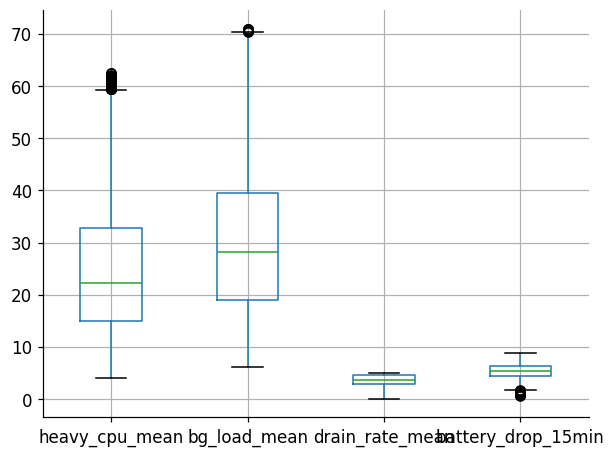

In [7]:
###########################
# Box plot for each unique features graph
###########################
'''
These skewness,kurtoris, box plot are used to understand the distribution of the data, identify outliers, and assess the symmetry and peakedness of the features. These are done as a part of EDA (Exploratory Data Analysis).
'''
dataset.boxplot(column=["heavy_cpu_mean", "bg_load_mean", "drain_rate_mean", "battery_drop_15min"])
plt.show()

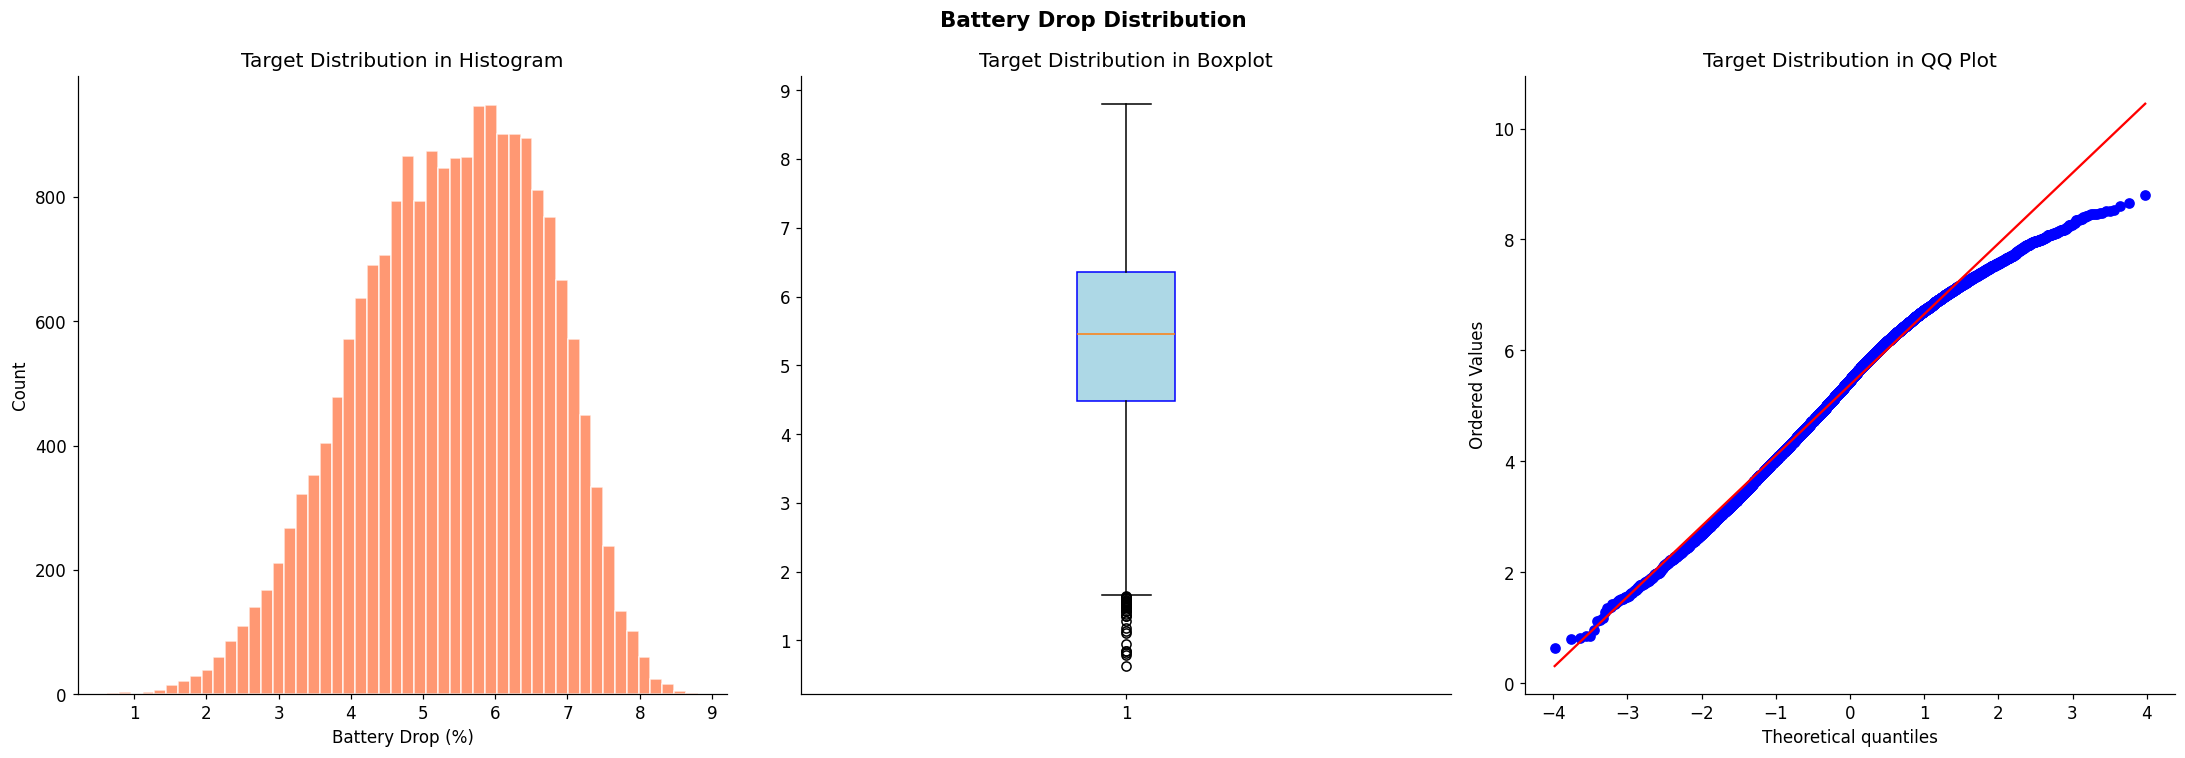

In [8]:
############################
# Battery Drop Distribution (target variable)
############################
''' 
Exploring target data with multiple graphs
'''

fig, axes = plt.subplots(1,3,figsize=(20,7))

# Histogram
axes[0].hist(dataset["battery_drop_15min"], bins=50, color="coral",alpha=0.8, edgecolor="white")
axes[0].set_title("Target Distribution in Histogram")
axes[0].set_xlabel("Battery Drop (%)")
axes[0].set_ylabel("Count")

# boxplot
axes[1].boxplot(dataset["battery_drop_15min"], vert=True, patch_artist=True, boxprops=dict(facecolor="lightblue", color="blue"))
axes[1].set_title("Target Distribution in Boxplot")


# QQ plot
# This plot is used to check if the data is normally distrbuted or not.
# If points algins along the line then ND else not ND
# If points deviate initially then right skewed and if points deviate at the end then left skewed
stats.probplot(dataset["battery_drop_15min"], dist="norm", plot=axes[2])
axes[2].set_title("Target Distribution in QQ Plot")

plt.suptitle("Battery Drop Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### **Step 2:** 

#### Correlation Analysis

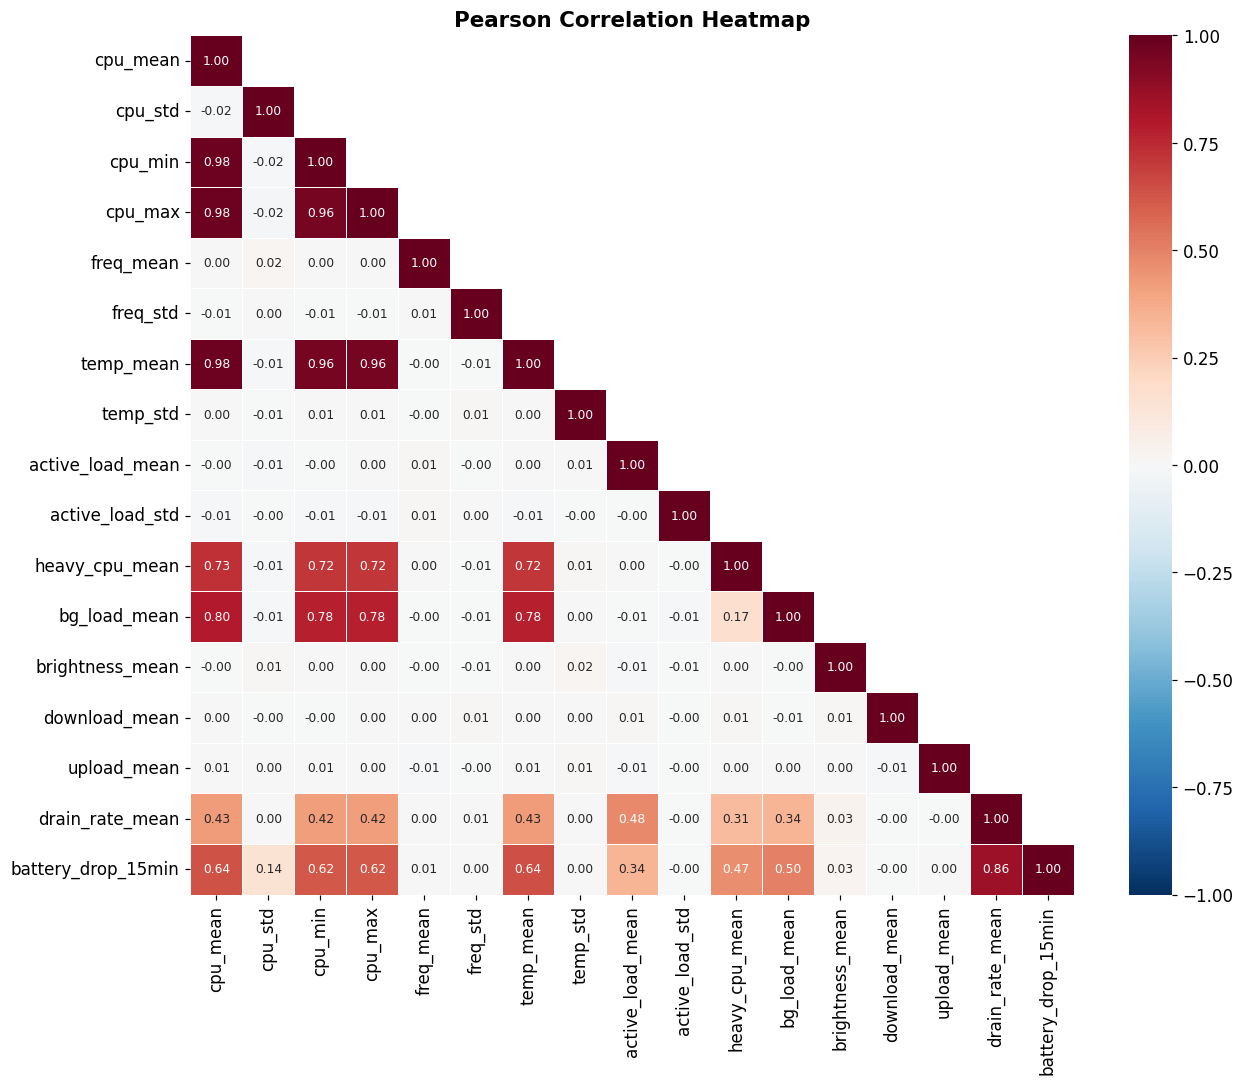

In [9]:
############################
# Using Pearson Correlation to find correlation between features and target variable
############################

corr_matrix = dataset.corr()

fig, axes = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, 
    fmt = ".2f", cmap="RdBu_r", center=0, 
    vmin=-1 , vmax=1, linewidths=0.5, ax=axes,
    annot_kws={"size": 8}
)
axes.set_title("Pearson Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
######################################
# Removing feature based on correlation
######################################
''' 
Removing all feature that correlate less than 0.1 with target variable.

Here,
brightness_mean       0.026859
freq_mean             0.007723
upload_mean           0.003485
freq_std              0.002594
temp_std              0.001702
download_mean        -0.000287
active_load_std      -0.002620

But including some features as MLP can capture non-linear relaitonship between features and target variable.

Here only removing,
freq_std              0.002594
temp_std              0.001702
download_mean        -0.000287
active_load_std      -0.002620

Negative correlation means when a feature increase then target decreases.
Here, negative but still near zero so very very weak realtion with target variable.

Also removing redundant features whose correlation with each other is same or more than 0.9

Here removing,
cpu_min
cpu_max
'''
FINAL_FEATURES = [
    "cpu_mean","cpu_std",
    "freq_mean",
    "temp_mean",
    "active_load_mean",
    "heavy_cpu_mean","bg_load_mean",
    "brightness_mean",
    "download_mean","upload_mean",
    "drain_rate_mean"
]

TARGET = "battery_drop_15min"

X = dataset[FINAL_FEATURES].values
y = dataset[TARGET].values

print(f"\nFinal feature matrix: {X.shape}")
print(f"Features: {FINAL_FEATURES}")



Final feature matrix: (20000, 11)
Features: ['cpu_mean', 'cpu_std', 'freq_mean', 'temp_mean', 'active_load_mean', 'heavy_cpu_mean', 'bg_load_mean', 'brightness_mean', 'download_mean', 'upload_mean', 'drain_rate_mean']


### **Step 3:** 

#### Split data into Train/Test/Validation (TTV)

Split is generally done in 80/10/10 rule. But, here Train data is 75% whereas test & Valid data are in 15%

In [108]:
######################################
# TTV Split
######################################

X_temp, X_test, y_temp, y_test = train_test_split(X,y, test_size=0.15, random_state=SEED) # 15% of 100% for test and remaining 85% for temporary train+val set
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp, test_size=0.1765, random_state=SEED) # 17.65% of 85% which is 15% for val and 70% remaining for train dataset

print(f"Train size : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val size   : {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test size  : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")


# StandardScaler — fit ONLY on train to prevent data leakage
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Scale target (z-score) — makes training more stable for regression
y_mean, y_std = y_train.mean(), y_train.std()
y_train = (y_train - y_mean) / y_std
y_val   = (y_val   - y_mean) / y_std
y_test  = (y_test  - y_mean) / y_std

print(f"Target  mean={y_mean:.3f}  std={y_std:.3f}")

Train size : 13999 (70.0%)
Val size   : 3001 (15.0%)
Test size  : 3000 (15.0%)
Target  mean=5.372  std=1.284


### **Step 4:** 

#### II. MLP from Scratch (Using Numpy + Python)

In [12]:
class MLP:
    ''' 
    Architecture: Input -> Dense(wiring) -> ReLU -> Dense(wiring) -> ReLU -> Dense(wiring) -> Linear
    Loss: MSE (Mean Squared Error)
    Optimizer: Mini-batch Gradient Descent
     - Batch Size: 32
     - Learning Rate: 0.001
    No use of normal gradient descent where each error is calculated for each data point and then weights are updated.
    Instead batch gradient descent where for single batch have a single error and then weights are updated.
        
    '''
    def __init__(self, layer_sizes,learning_rate=0.01,l2_lambda=0.0,seed=42):
        '''
        Layer size is a list of number of neurons in each layer including input and output layer.
        eg: [12(input), 64(hidden), 32(hidden), 1(output)(linear)] 
        '''
        
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.seed = np.random.seed(seed)
        self.n_dense_layers = len(layer_sizes) - 1
        self.train_losses, self.val_losses = [], []
        
        # He initialization for weights and zero initialization for biases (better for ReLU activation function)
        # Here, W have 3 W matrices of shapes (12,64), (64,32) and (32,1) for above eg layer size 
        self.W = [np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0/layer_sizes[i]) for i in range(self.n_dense_layers)]
        self.b = [np.zeros((1,layer_sizes[i+1])) for i in range(self.n_dense_layers)]
       
    # Activation function initialization
    def relu(self, z): 
        ''' 
        Here, if z is greater then 0 then return z else return 0.
        '''
        return np.maximum(0,z)
    def relu_grad(self,z):
        ''' 
        Here, if z is greater then 0 then return 1 else return 0
        This is used in backpropagation to calculate the gradient of the loss with respect to the weights and biases
        '''
        return (z > 0).astype(float)
    
    def forward(self, X):
        self._cache = [] # storing immediate input and output of each layer for backpropagation
        A = X
        for i in range(self.n_dense_layers):
            Z = A @ self.W[i] + self.b[i] # Here, @ is matrix multiplication operator in python which is used to calculate the output of each layer by multiplying the input with weights and adding the bias.
            self._cache.append((A,Z))
            A = self.relu(Z) if i < self.n_dense_layers -1 else Z # here, for lastlayer no activation function is used but instead linear output is used
            # there in A, self.n_dense_laysers-1 is used because of indexing starting from 0 so end of loop in 1 not 2 if layer size is 3
        return A
    
    def loss(self, y_pred, y_true):
        ''' 
        We will be using MSE and L2 Ridge regularization for loss calculation.
        '''
        n = len(y_true)
        mse_loss = np.mean((y_pred - y_true) ** 2)
        l2 = (self.l2_lambda / (2 * n)) * sum(np.sum(Wi ** 2) for Wi in self.W)
        return mse_loss + l2

    # backpropagation
    def backward(self, y_pred, y_true):
        '''
        Here, vanilla gradient descent is used to update the weigths and biases to it's optimal value to minimize the loss function. 
        '''
        n = len(y_true)
        dA = (2/n) * (y_pred.flatten() - y_true).reshape(-1, 1)
        for i in reversed(range(self.n_dense_layers)): 
            A_prev, Z = self._cache[i]
            dZ = dA * self.relu_grad(Z) if i < self.n_dense_layers - 1 else dA
            dW = A_prev.T @ dZ / n + (self.l2_lambda/n) * self.W[i]  # L2 gradient
            db = np.mean(dZ, axis=0, keepdims=True)
            dA = dZ @ self.W[i].T
            self.W[i] -= self.learning_rate * dW
            self.b[i] -= self.learning_rate * db
            
    def train(self, X_train, y_train, X_val, y_val, epochs=200, batch_size=32, verbose=True):
        '''
        Here, mini-batch gradient descent is used for training the model. 
        '''
        n = len(X_train)
        for epoch in range(1, epochs+1):
            shuffle_data_index= np.random.permutation(n)
            epoch_loss, nb = 0.0, 0 
            for start in range(0, n, batch_size):
                Xb, yb = X_train[shuffle_data_index[start:start+batch_size]], y_train[shuffle_data_index[start:start+batch_size]]
                pred = self.forward(Xb) # each batch is send to the forward pass to calculate the predicted output i.e A variable which is activated output
                epoch_loss += self.loss(pred, yb); nb += 1
                self.backward(pred, yb)
                print(f"Batch {start//batch_size + 1}/{(n-1)//batch_size + 1} | Batch Loss: {self.loss(pred, yb):.5f}", end="\r")
            val_loss = self.loss(self.forward(X_val), y_val)
            self.train_losses.append(epoch_loss/nb)
            self.val_losses.append(val_loss)
            if verbose and (epoch % 20 == 0 or epoch == 1):
                print(f"  Epoch {epoch:4d}/{epochs} | Train: {epoch_loss/nb:.5f} | Val: {val_loss:.5f}")
                
    def predict(self, X):
        return self.forward(X).flatten()

In [13]:
#############################################
# Initializing and training the MLP model
#############################################

input_features = X_train.shape[1]
mlp_basic = MLP([input_features, 64, 32, 1], learning_rate=0.001, l2_lambda=0.001, seed=SEED)

total_weights_and_biases = sum(w.size + b.size for w,b in zip(mlp_basic.W,mlp_basic.b))

print(f"Architecture of MLP : {mlp_basic.layer_sizes}")
print(f"Total Weights and Biases : {total_weights_and_biases}")
print("\nTraining Basic MLP...")
mlp_basic.train(X_train, y_train, X_val, y_val, epochs=200, batch_size=1, verbose=True)

Architecture of MLP : [11, 64, 32, 1]
Total Weights and Biases : 2881

Training Basic MLP...
  Epoch    1/200 | Train: 0.30148 | Val: 1.95102
  Epoch   20/200 | Train: 0.20815 | Val: 1.90318
  Epoch   40/200 | Train: 0.18272 | Val: 1.91655
  Epoch   60/200 | Train: 0.16984 | Val: 1.85445
  Epoch   80/200 | Train: 0.16326 | Val: 1.94188
  Epoch  100/200 | Train: 0.15949 | Val: 1.94662
  Epoch  120/200 | Train: 0.15788 | Val: 1.94296
  Epoch  140/200 | Train: 0.15644 | Val: 1.86422
  Epoch  160/200 | Train: 0.15623 | Val: 1.97734
  Epoch  180/200 | Train: 0.15565 | Val: 1.90637
  Epoch  200/200 | Train: 0.15532 | Val: 1.90866


#### II. MLP from Pytorch for advance MLP

In [16]:
###########################
#  PyTorch Data Setup
###########################

import torch
from torch.utils.data import DataLoader, TensorDataset

def make_tensors(X, y):
    return (
        torch.FloatTensor(X),
        torch.FloatTensor(y).unsqueeze(1)
    )

# all data is converted to PyTorch tensors and then wrapped in TensorDataset and DataLoader for easy use in training loop
X_tr_t, y_tr_t = make_tensors(X_train, y_train)
X_va_t, y_va_t = make_tensors(X_val,   y_val)
X_te_t, y_te_t = make_tensors(X_test,  y_test)

train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_dataset_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [17]:
###########################
#  MLP in Pytorch
###########################

import torch.nn as nn

class MLPTorch(nn.Module):
    """
    Using PyTorch's nn.Module so that we can define a flexible MLP architecture.
    Flexible MLP in PyTorch supports following features:
      - Configurable hidden sizes
      - Dropout after each hidden layer
      - BatchNorm after each hidden layer
      - Activations
    """

    def __init__(
        self, input_dimension, hidden_sizes=[64, 32],
        dropout_rate=0.0, use_batchnorm=False
    ):
        super().__init__()
        layers = []
        prev_size = input_dimension

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = h

        layers.append(nn.Linear(prev_size, 1))   # output layer (regression)
        self.net = nn.Sequential(*layers)

        # Initializing weights and biases
        self._init_weights_and_biases()

    def _init_weights_and_biases(self):
        """
        Here, using He (Kaiming) initialization for ReLU layers
        And zeros for biases
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [47]:
##########################################################
#  Training Function (supports L1, L2, optimizer choice)
###########################################################

def train_pytorch(
    model, train_loader, X_val, y_val,
    optimizer, epochs=200,
    l1_lambda=0.0, l2_lambda=0.0,
    scheduler=None, verbose=True
):
    """
    Train PyTorch MLP
    """
    
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []

        for Xb, yb in train_loader:
            optimizer.zero_grad()

            # Forward pass
            y_pred = model(Xb)
            loss   = criterion(y_pred, yb) # MSE Loss calculation is done here

            # L1 Regularization used (lasso regression) where unimportant features are pushed towards zero and important features are kept with non-zero weights. This is done by adding the absolute value of the weights to the loss function.
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_penalty

            # L2 Regularization (Rideg regression) where all features are kept but their weights are pushed towards zero. This is done by adding the square of the weights to the loss function.
            if l2_lambda > 0:
                l2_penalty = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l2_lambda * l2_penalty

            # Backpropagation and optimization step
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # Here, evaluating model on the validation set at the end of each epoch. Dropout and BatchNorm are disabled during evaluation to get a stable estimate of the model's performance on unseen data. The validation loss is calculated using the same criterion (MSE) as in training, but without the regularization terms.
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        # Here, if a learning rate scheduler is provided, we step it at the end of each epoch to adjust the learning rate according to the defined schedule
        if scheduler:
            scheduler.step(val_loss)  # For ReduceLROnPlateau, we step with the latest validation loss

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f"  Epoch {epoch:4d}/{epochs} | "
                  f"Train: {train_losses[-1]:.5f} | "
                  f"Val: {val_losses[-1]:.5f}")

    return train_losses, val_losses


## **Experiments**


#### A. MLP from Scratch (Using Numpy + Python)

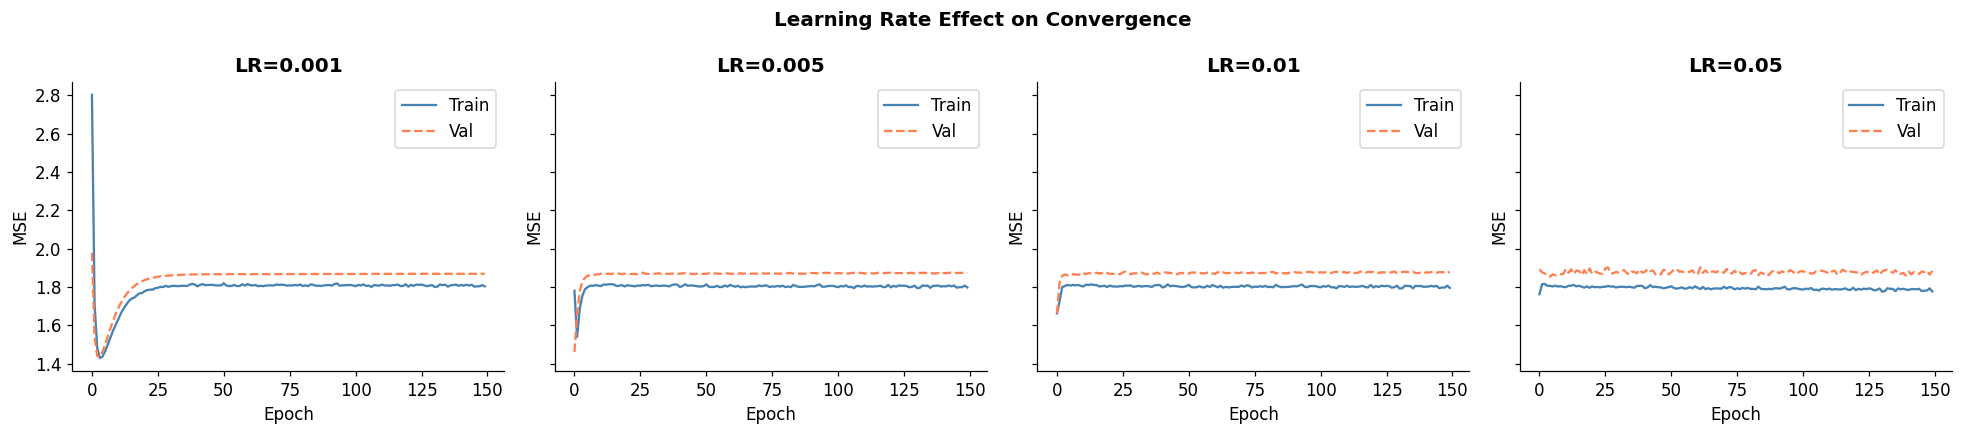

In [39]:
#############################################
# Learning Rate Experimentation
#############################################

learning_rates = [0.001, 0.005, 0.01, 0.05]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, lr in zip(axes, learning_rates):
    m = MLP([input_features, 64, 32, 1], learning_rate=lr, l2_lambda=0.01)
    m.train(X_train, y_train, X_val, y_val, epochs=150, batch_size=32, verbose=False)
    ax.plot(m.train_losses, color='steelblue', label='Train')
    ax.plot(m.val_losses,   color='coral', linestyle='--', label='Val')
    ax.set_title(f'LR={lr}', fontweight='bold') 
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
plt.suptitle('Learning Rate Effect on Convergence', fontsize=13, fontweight='bold')
plt.tight_layout()

#### B. MLP from Pytorch for advance MLP

In [20]:
###########################################
#  EXPERIMENT 1: MLP without Regularization
###########################################

from torch import optim

torch.manual_seed(SEED)
model_base = MLPTorch(input_features, hidden_sizes=[64, 32], dropout_rate=0.0, use_batchnorm=False)
# Adam optimizer is used to adjust the learning rate automatically during training to update the weights and biases to minimize the loss function efficeintly and effectively.
opt_base   = optim.Adam(model_base.parameters(), lr=0.001)

tl_base, vl_base = train_pytorch(
    model_base, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_base, epochs=200, verbose=True
)

  Epoch    1/200 | Train: 0.30769 | Val: 0.18020
  Epoch   20/200 | Train: 0.14974 | Val: 0.16076
  Epoch   40/200 | Train: 0.14367 | Val: 0.16365
  Epoch   60/200 | Train: 0.13953 | Val: 0.16925
  Epoch   80/200 | Train: 0.13663 | Val: 0.17479
  Epoch  100/200 | Train: 0.13426 | Val: 0.17928
  Epoch  120/200 | Train: 0.13206 | Val: 0.17746
  Epoch  140/200 | Train: 0.13036 | Val: 0.17979
  Epoch  160/200 | Train: 0.12849 | Val: 0.18281
  Epoch  180/200 | Train: 0.12803 | Val: 0.18486
  Epoch  200/200 | Train: 0.12670 | Val: 0.18403


In [21]:
###########################################
#  EXPERIMENT 2: L2 Regularization
###########################################

from torch import optim

torch.manual_seed(SEED)
model_l2 = MLPTorch(input_features, hidden_sizes=[64, 32])
# Here, using Adam optimizer with weight_decay which is equivalent to L2 regularization (Ridge regression)
opt_l2   = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=1e-3)

tl_l2, vl_l2 = train_pytorch(
    model_l2, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_l2, epochs=200, verbose=True
)


── L2 Regularization (weight_decay=1e-3) ──
  Epoch    1/200 | Train: 0.30689 | Val: 0.17944
  Epoch   20/200 | Train: 0.15271 | Val: 0.15613
  Epoch   40/200 | Train: 0.15261 | Val: 0.15336
  Epoch   60/200 | Train: 0.15226 | Val: 0.15615
  Epoch   80/200 | Train: 0.15209 | Val: 0.15685
  Epoch  100/200 | Train: 0.15185 | Val: 0.15591
  Epoch  120/200 | Train: 0.15156 | Val: 0.15509
  Epoch  140/200 | Train: 0.15103 | Val: 0.15676
  Epoch  160/200 | Train: 0.15068 | Val: 0.15556
  Epoch  180/200 | Train: 0.15085 | Val: 0.15630
  Epoch  200/200 | Train: 0.15094 | Val: 0.15686


In [22]:
###########################################
#  EXPERIMENT 3: L1 Regularization
###########################################

from torch import optim

torch.manual_seed(SEED)
model_l1 = MLPTorch(input_features, hidden_sizes=[64, 32])
opt_l1   = optim.Adam(model_l1.parameters(), lr=0.001)

# Here, to apply L1 regularization, we manually add the L1 penalty to the loss function
tl_l1, vl_l1 = train_pytorch(
    model_l1, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_l1, epochs=200,
    l1_lambda=1e-4, verbose=True
)


── L1 Regularization (lambda=1e-4) ──
  Epoch    1/200 | Train: 0.35934 | Val: 0.18014
  Epoch   20/200 | Train: 0.18136 | Val: 0.15811
  Epoch   40/200 | Train: 0.16648 | Val: 0.15438
  Epoch   60/200 | Train: 0.16106 | Val: 0.15574
  Epoch   80/200 | Train: 0.15889 | Val: 0.15675
  Epoch  100/200 | Train: 0.15803 | Val: 0.15647
  Epoch  120/200 | Train: 0.15734 | Val: 0.15553
  Epoch  140/200 | Train: 0.15653 | Val: 0.15671
  Epoch  160/200 | Train: 0.15620 | Val: 0.15613
  Epoch  180/200 | Train: 0.15608 | Val: 0.15641
  Epoch  200/200 | Train: 0.15616 | Val: 0.15705


In [23]:
###########################################
#  EXPERIMENT 4: Dropout Regularization
###########################################

from torch import optim

torch.manual_seed(SEED)
# Here, dropout rate is set to 0.3, which means for each hidden layer, 30% of the neurons will be randomly dropped during training to prevent overfitting and improve generalization 
model_drop = MLPTorch(input_features, hidden_sizes=[64, 32], dropout_rate=0.3)
opt_drop   = optim.Adam(model_drop.parameters(), lr=0.001)

tl_drop, vl_drop = train_pytorch(
    model_drop, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_drop, epochs=200, verbose=True
)



── Dropout Regularization (p=0.3) ──
  Epoch    1/200 | Train: 0.77644 | Val: 0.23453
  Epoch   20/200 | Train: 0.19918 | Val: 0.15696
  Epoch   40/200 | Train: 0.18922 | Val: 0.15685
  Epoch   60/200 | Train: 0.18533 | Val: 0.16003
  Epoch   80/200 | Train: 0.18485 | Val: 0.16145
  Epoch  100/200 | Train: 0.18217 | Val: 0.16310
  Epoch  120/200 | Train: 0.18048 | Val: 0.16016
  Epoch  140/200 | Train: 0.18142 | Val: 0.15669
  Epoch  160/200 | Train: 0.18082 | Val: 0.15739
  Epoch  180/200 | Train: 0.18136 | Val: 0.16375
  Epoch  200/200 | Train: 0.18227 | Val: 0.16156


In [24]:
###########################################
#  EXPERIMENT 5: Batch Normalization
###########################################

from torch import optim

torch.manual_seed(SEED)
# Here, batch normatizaiton is applied. This normalizes the output of each hidden layer (activation output) to stabalize and accelerate training 
model_bn = MLPTorch(input_features, hidden_sizes=[64, 32], use_batchnorm=True)
opt_bn   = optim.Adam(model_bn.parameters(), lr=0.001)

tl_bn, vl_bn = train_pytorch(
    model_bn, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_bn, epochs=200, verbose=True
)


── Batch Normalization ──
  Epoch    1/200 | Train: 0.31474 | Val: 0.18115
  Epoch   20/200 | Train: 0.18464 | Val: 0.16212
  Epoch   40/200 | Train: 0.17930 | Val: 0.16147
  Epoch   60/200 | Train: 0.17319 | Val: 0.16490
  Epoch   80/200 | Train: 0.16759 | Val: 0.16640
  Epoch  100/200 | Train: 0.16790 | Val: 0.16430
  Epoch  120/200 | Train: 0.16304 | Val: 0.16343
  Epoch  140/200 | Train: 0.16188 | Val: 0.16811
  Epoch  160/200 | Train: 0.16042 | Val: 0.16401
  Epoch  180/200 | Train: 0.16200 | Val: 0.16634
  Epoch  200/200 | Train: 0.16040 | Val: 0.16504


In [113]:
###########################################
#  EXPERIMENT 6: Dropout + BatchNorm + L2 
###########################################

torch.manual_seed(SEED)
model_combo = MLPTorch(input_features, hidden_sizes=[128, 64, 32], dropout_rate=0.2, use_batchnorm=True)
opt_combo   = optim.Adam(model_combo.parameters(), lr=0.001, weight_decay=1e-4)
# Learning rate scheduler is applied to reduce the learning rate by a factor of 0.5 if the validation loss does not improve for 20 consecutive epochs helping in fine-tuning the learning process and outputing a better model
scheduler= optim.lr_scheduler.ReduceLROnPlateau(opt_combo, 'min', patience=20, factor=0.5)

tl_best, vl_best = train_pytorch(
    model_combo, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_combo, epochs=200, scheduler=scheduler, verbose=True)

  Epoch    1/200 | Train: 0.63302 | Val: 0.20555
  Epoch   20/200 | Train: 0.21028 | Val: 0.15813
  Epoch   40/200 | Train: 0.20715 | Val: 0.15835
  Epoch   60/200 | Train: 0.20285 | Val: 0.16264
  Epoch   80/200 | Train: 0.20342 | Val: 0.15733
  Epoch  100/200 | Train: 0.20161 | Val: 0.15784
  Epoch  120/200 | Train: 0.19456 | Val: 0.16207
  Epoch  140/200 | Train: 0.19709 | Val: 0.15726
  Epoch  160/200 | Train: 0.19968 | Val: 0.15944
  Epoch  180/200 | Train: 0.19558 | Val: 0.15723
  Epoch  200/200 | Train: 0.19526 | Val: 0.15752


In [26]:
###########################################
#  EXPERIMENT 7: SGD with Momentum and Nesterov 
# ###########################################

from torch import optim

torch.manual_seed(SEED)
model_sgd = MLPTorch(input_features, hidden_sizes=[64, 32], dropout_rate=0.2, use_batchnorm=True)
# Nesterov momentum helps for look ahead before taking the step
opt_sgd   = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)

tl_sgd, vl_sgd = train_pytorch(
    model_sgd, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_sgd, epochs=200, verbose=True
)


── SGD (Nesterov Momentum=0.9) ──
  Epoch    1/200 | Train: 0.32059 | Val: 0.16782
  Epoch   20/200 | Train: 0.22346 | Val: 0.15547
  Epoch   40/200 | Train: 0.21464 | Val: 0.15788
  Epoch   60/200 | Train: 0.21730 | Val: 0.16064
  Epoch   80/200 | Train: 0.21081 | Val: 0.16121
  Epoch  100/200 | Train: 0.20998 | Val: 0.15959
  Epoch  120/200 | Train: 0.20956 | Val: 0.15484
  Epoch  140/200 | Train: 0.21137 | Val: 0.15564
  Epoch  160/200 | Train: 0.21114 | Val: 0.15812
  Epoch  180/200 | Train: 0.20859 | Val: 0.16144
  Epoch  200/200 | Train: 0.21197 | Val: 0.16365


## **Dataset Description**

This assigment use simulated data of different measurable metrics of the laptop that influence the battery drain.

Columns: session_id, timestamp, battery_percent, cpu_usage, cpu_freq_avg, cpu_temp_package, total_processes, heavy_processes, active_load, heavy_cpu_usage, bg_load, brightness_norm, download_rate, upload_rate, drain_rate_5min
Extra Column (label for output): This will be derived from the existing feature "battery_precent". This results exclusion of the rows that doesn't have future battery reference to calculate battery drain percentage.

 

## **Results**

The ouput from MLP created from Numpy and Tensor can be seen in two parts:

### A. Results from scratch MLP from NumPy (Scratch)

In [34]:
#############################################
# Evaluating the MLP model
#############################################

def evaluate_model(prediction_function, X, y_true, label=""):
    y_pred = prediction_function(X)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label != "Test_2":
        print(f"{label:15s} → RMSE={rmse:.4f}%  MAE={mae:.4f}%  R²={r2:.4f}")
    # Rescaling predictions back to original scale for better visualization
    y_pred = y_pred * y_std + y_mean
    y_true = y_true * y_std + y_mean
    return y_pred, y_true, {'rmse': rmse, 'mae': mae, 'r2': r2}

Basic MLP Results:
Train           → RMSE=0.3816%  MAE=0.3047%  R²=0.8544
Validation      → RMSE=0.4028%  MAE=0.3189%  R²=0.8395
Test            → RMSE=0.3994%  MAE=0.3220%  R²=0.8348


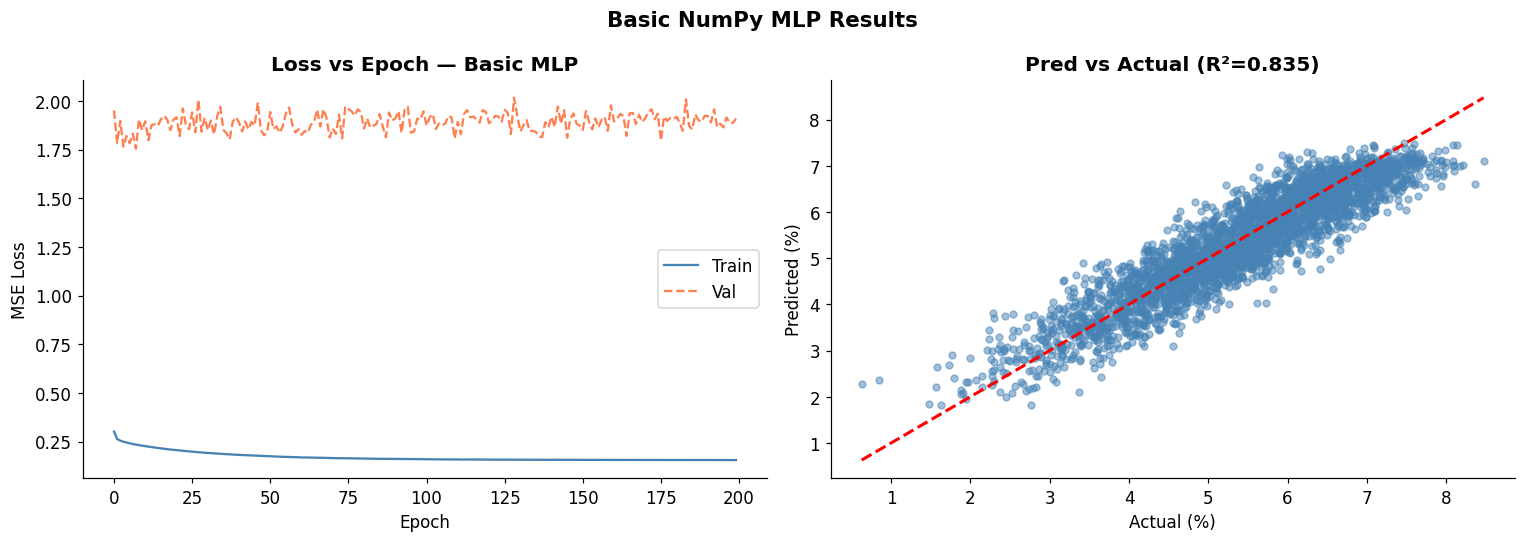

In [35]:
#############################################
# Results and Visualizations for MLP (Created from Scratch using NumPy)
#############################################

print("Basic MLP Results:")
evaluate_model(mlp_basic.predict, X_train, y_train, 'Train')
evaluate_model(mlp_basic.predict, X_val, y_val, 'Validation')
_, _, basic_test = evaluate_model(mlp_basic.predict, X_test, y_test, 'Test')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mlp_basic.train_losses, color='steelblue', label='Train')
axes[0].plot(mlp_basic.val_losses,   color='coral', linestyle='--', label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss vs Epoch — Basic MLP', fontweight='bold'); axes[0].legend()

y_test_pred, y_true, _ = evaluate_model(mlp_basic.predict, X_test, y_test, 'Test_2')
axes[1].scatter(y_true, y_test_pred, alpha=0.5, s=20, color='steelblue')
lims = [min(y_true.min(), y_test_pred.min()), max(y_true.max(), y_test_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=2)
axes[1].set_xlabel('Actual (%)'); axes[1].set_ylabel('Predicted (%)')
axes[1].set_title(f'Pred vs Actual (R²={basic_test["r2"]:.3f})', fontweight='bold')

plt.suptitle('Basic NumPy MLP Results', fontsize=14, fontweight='bold')
plt.tight_layout() 

### B. Results from scratch MLP created using Pytorch

In [63]:
#############################################
# Evaluating the MLP model
#############################################

# Evaluation function for pytorch MLP which rescales the predictions back to original units before calculating metrics
def get_metrics_torch(model, X_t, y_true, y_mean, y_std):
    """Evaluate PyTorch model, rescale to original units."""
    model.eval()
    with torch.no_grad():
        y_pred_s = model(X_t).numpy().flatten()
    y_pred = y_pred_s * y_std + y_mean
    y_true = y_true * y_std + y_mean
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae' : mean_absolute_error(y_true, y_pred),
        'r2'  : r2_score(y_true, y_pred)
    }, y_pred

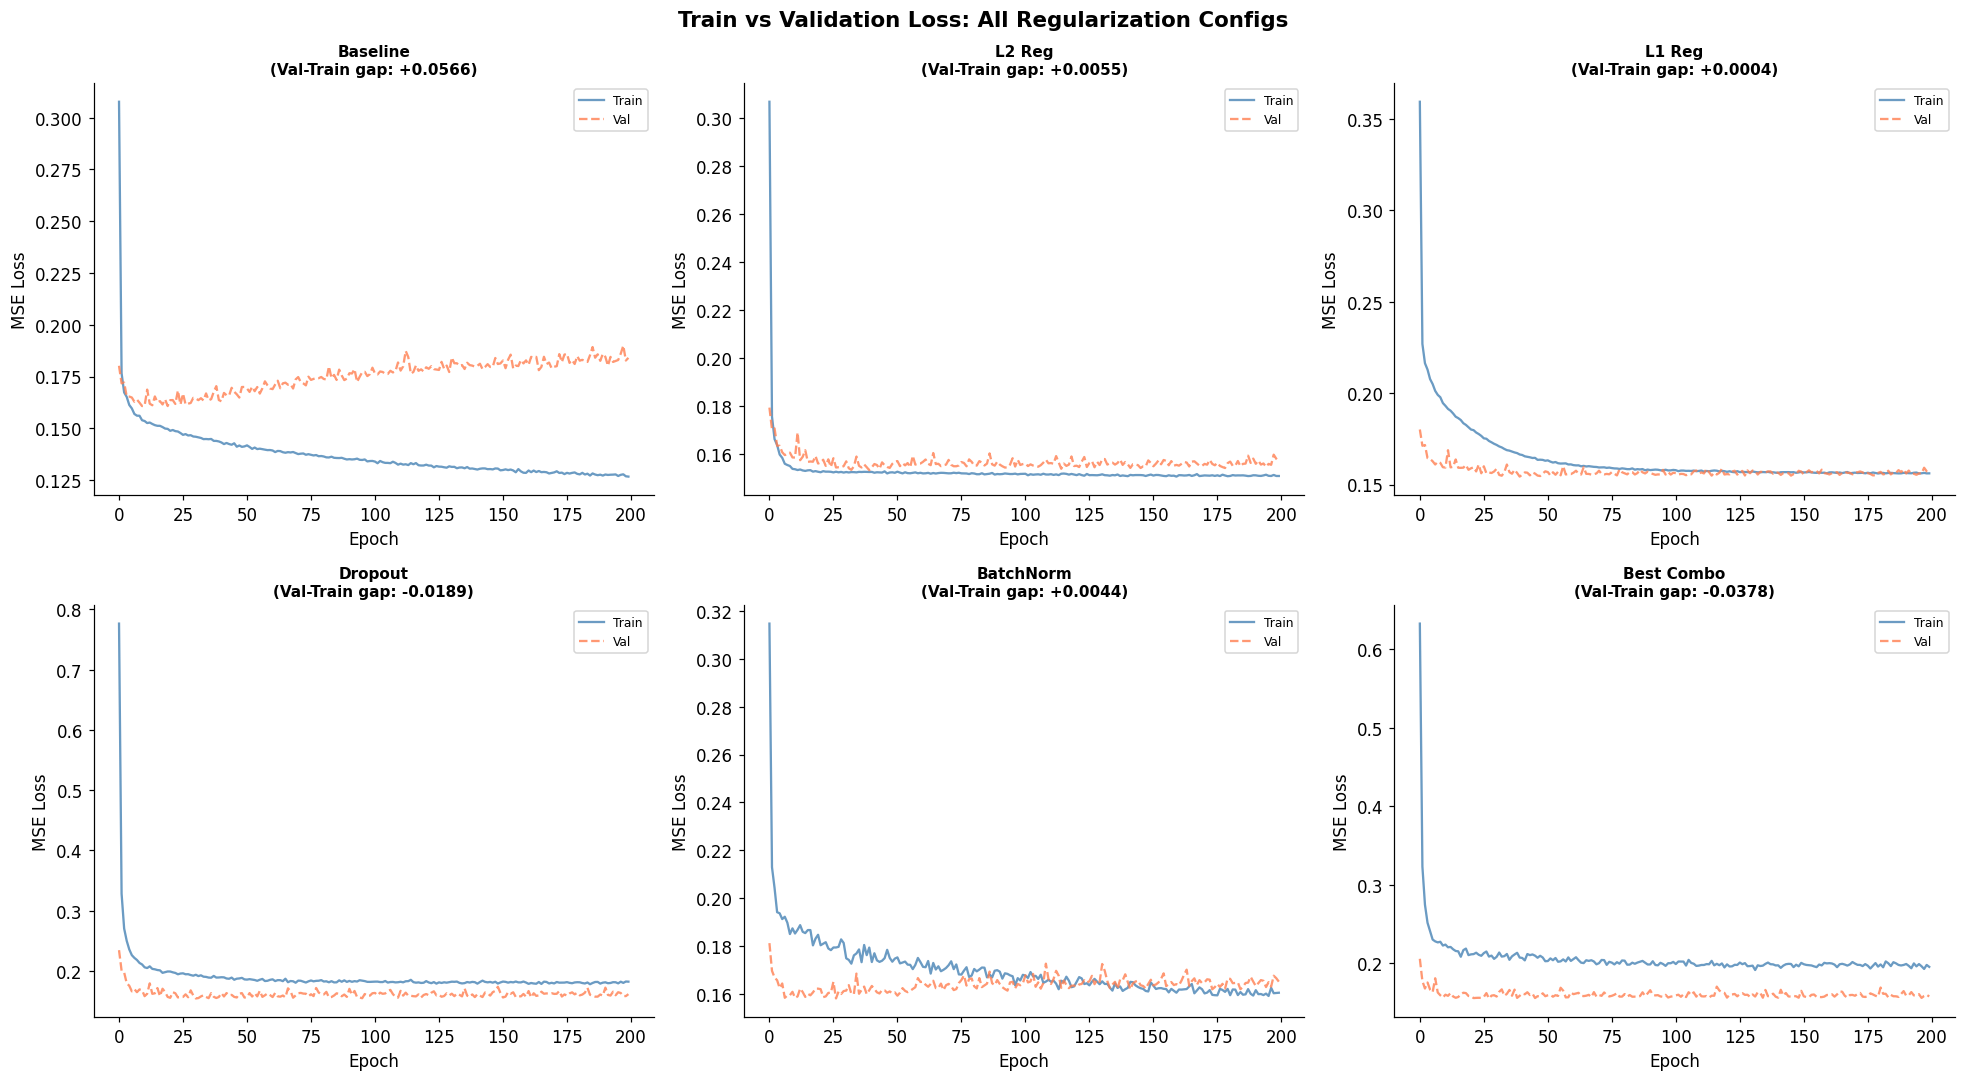

In [ ]:
###########################################
#  Regularization Comparison Plots
###########################################

configs = {
    'Baseline':    (tl_base, vl_base, model_base),
    'L2 Reg':      (tl_l2,   vl_l2,   model_l2),
    'L1 Reg':      (tl_l1,   vl_l1,   model_l1),
    'Dropout':     (tl_drop, vl_drop, model_drop),
    'BatchNorm':   (tl_bn,   vl_bn,   model_bn),
    'Best Combo':  (tl_best, vl_best, model_combo),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

results_table = {}

for ax, (name, (tl, vl, model)) in zip(axes, configs.items()):
    ax.plot(tl, label='Train', color='steelblue', alpha=0.8)
    ax.plot(vl, label='Val',   color='coral',     linestyle='--', alpha=0.8)

    # Gap between train and val (proxy for overfitting)
    gap = np.mean(np.array(vl[-20:]) - np.array(tl[-20:]))
    ax.set_title(f'{name}\n(Val-Train gap: {gap:+.4f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)

    # Collect metrics
    m, _ = get_metrics_torch(model, X_te_t, y_test, y_mean, y_std)
    results_table[name] = {**m, 'gap': gap}

plt.suptitle('Train vs Validation Loss: All Regularization Configs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regularization_comparison.png', bbox_inches='tight')
plt.show()

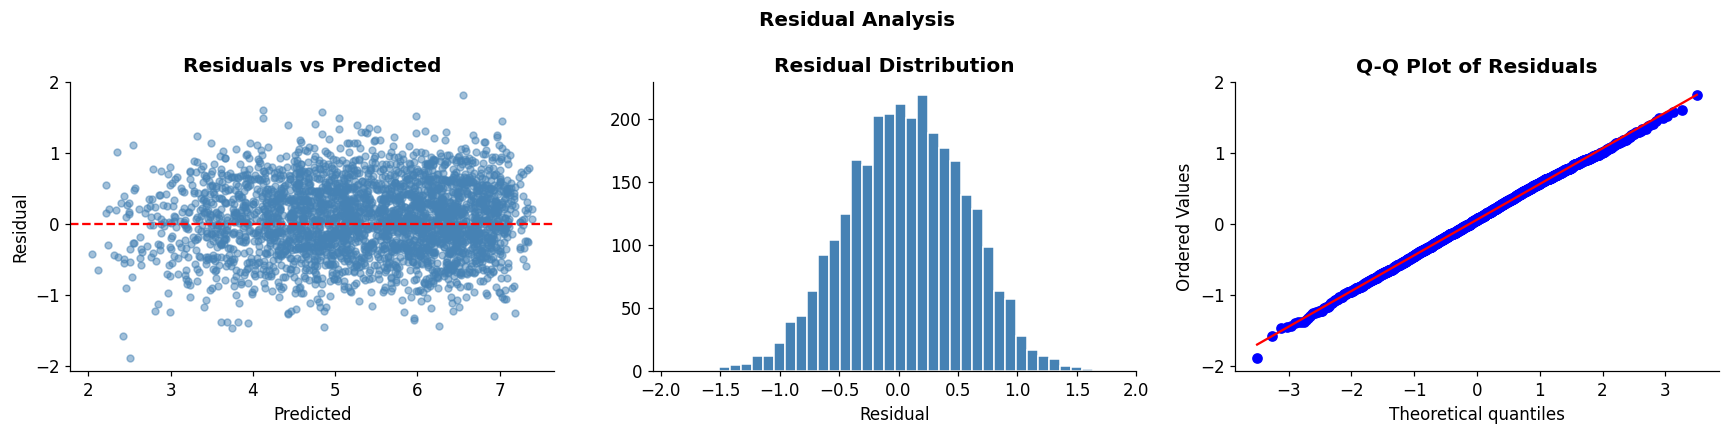

Residuals: mean=0.0631, std=0.5015
Max error: 1.8835%


In [ ]:
###########################################
#  Residual Analysis
###########################################

_, y_best_pred = get_metrics_torch(model_l1, X_te_t, y_test, y_mean, y_std)
y_test_rescaled = y_test * y_std + y_mean
residuals = y_test_rescaled - y_best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs Predicted
axes[0].scatter(y_best_pred, residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution', fontweight='bold')

# QQ plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residuals: mean={residuals.mean():.4f}, std={residuals.std():.4f}")
print(f"Max error: {np.abs(residuals).max():.4f}%")

## **Analysis & Discussion**

The insights from the experiments of hyperparameter tuning in neural networks are:

1. **Learning Rate Impact**: Initial model with lr=0.01 achieved only 23.3% test accuracy whereas lr=0.1 achieved 93.3% which demonstrates that learning rate is crucial for model convergence.

3. **Model Generalization**: The best model (lr=0.1) generalized well to unseen test data.

4. **Trade-off Observation**: When higher learning rates converge faster, they risk instability.

### A. SHAP Feature Importance Analysis

In [89]:
#################################################################
#  SHAP Analysis for Best MLP Model based on Previous Experiments
#################################################################

import shap

def model_predict(X_np):
    """
    best model is model_l1 based on previous experiments and evaluation metrics.
    """
    model_l1.eval()
    with torch.no_grad():
        preds = model_l1(torch.FloatTensor(X_np)).numpy().flatten()
    return preds

background = shap.kmeans(X_train, 50)

print("Computing SHAP values (KernelExplainer)... This may take ~1-2 minutes.")
explainer   = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(X_test[:100], nsamples=100)  # 100 test samples
print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values (KernelExplainer)... This may take ~1-2 minutes.


100%|██████████| 100/100 [00:00<00:00, 180.94it/s]

SHAP values shape: (100, 11)


/tmp/ipykernel_13331/4085975308.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


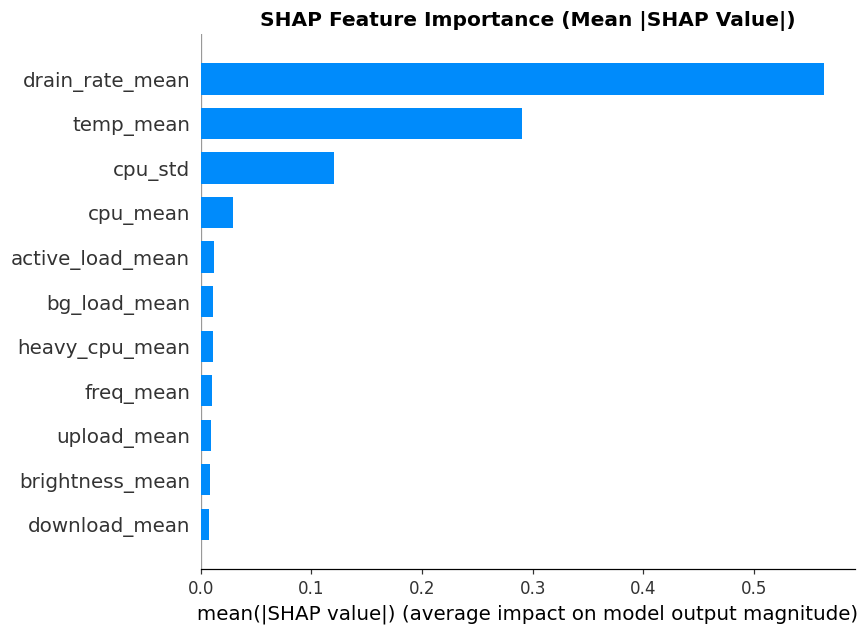

/tmp/ipykernel_13331/4085975308.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


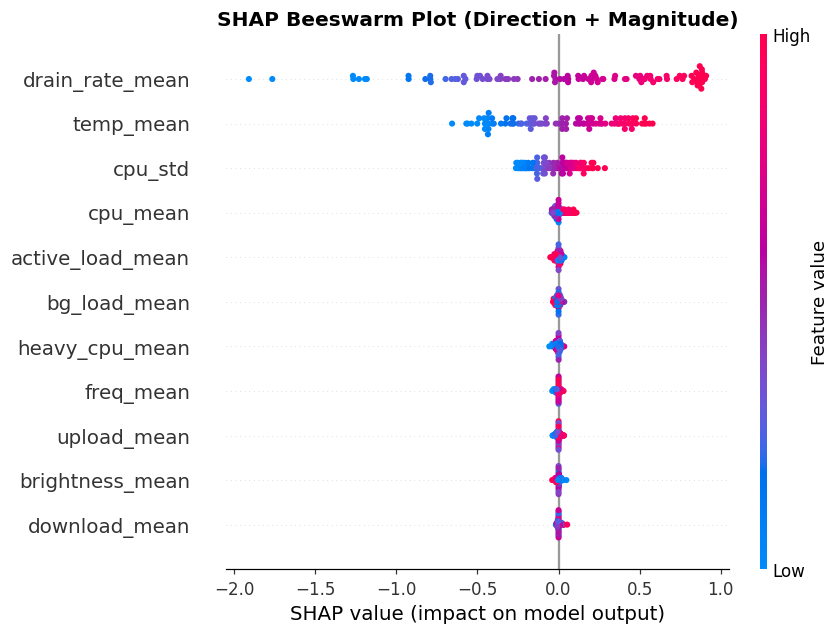

In [95]:
###########################################
#  SHAP Plots
###########################################

plt.figure(figsize=(10, 6))

# Bar plot (mean absolute SHAP value for each feature)
shap.summary_plot(
    shap_values, X_test[:100],
    feature_names=FINAL_FEATURES,
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontweight='bold')
plt.tight_layout()
plt.show()

# Beeswarm / Dot plot (shows direction + magnitude)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test[:100],
    feature_names=FINAL_FEATURES,
    plot_type='dot', show=False
)
plt.title('SHAP Beeswarm Plot (Direction + Magnitude)', fontweight='bold')
plt.tight_layout()
plt.show()

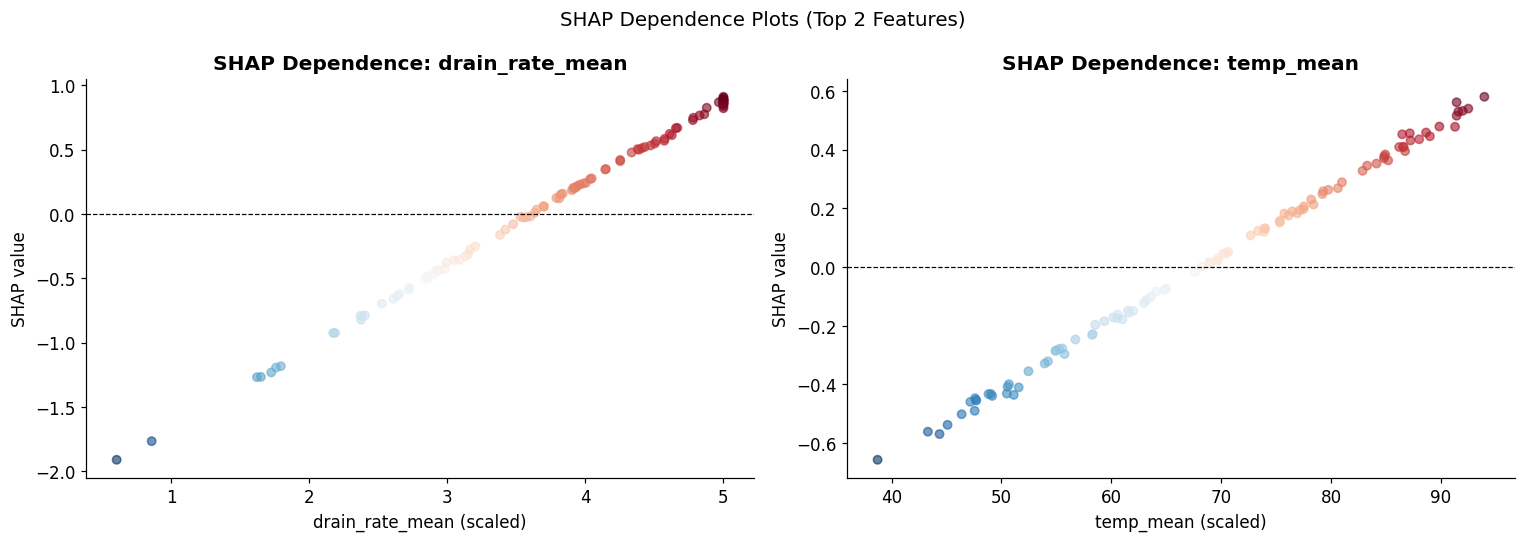


SHAP Feature Importance Ranking:
   1. drain_rate_mean           ██████████████████████████████ 0.5628
   2. temp_mean                 ███████████████                0.2906
   3. cpu_std                   ██████                         0.1202
   4. cpu_mean                  █                              0.0292
   5. active_load_mean                                         0.0123
   6. bg_load_mean                                             0.0113
   7. heavy_cpu_mean                                           0.0112
   8. freq_mean                                                0.0102
   9. upload_mean                                              0.0088
  10. brightness_mean                                          0.0087
  11. download_mean                                            0.0075


In [111]:
###########################################
# SHAP Dependence Plots (top 2 features)
###########################################

mean_shap = np.abs(shap_values).mean(axis=0)
top2_idx  = np.argsort(mean_shap)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_test_scaled = scaler.inverse_transform(X_test)

for ax, idx in zip(axes, top2_idx):
    feat_name = FINAL_FEATURES[idx]
    ax.scatter(
        X_test_scaled[:100, idx], shap_values[:, idx],
        c=shap_values[:, idx], cmap='RdBu_r',
        alpha=0.6, s=30
    )
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'{feat_name} (scaled)')
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP Dependence: {feat_name}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots (Top 2 Features)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight')
plt.show()

shap_importance = pd.Series(mean_shap, index=FINAL_FEATURES).sort_values(ascending=False)
print("\nSHAP Feature Importance Ranking:")
print("=" * 55)
for i, (feat, val) in enumerate(shap_importance.items(), 1):
    bar = '█' * int(val / shap_importance.max() * 30)
    print(f"  {i:2d}. {feat:<25} {bar:<30} {val:.4f}")

### B. Overfitting Analysis

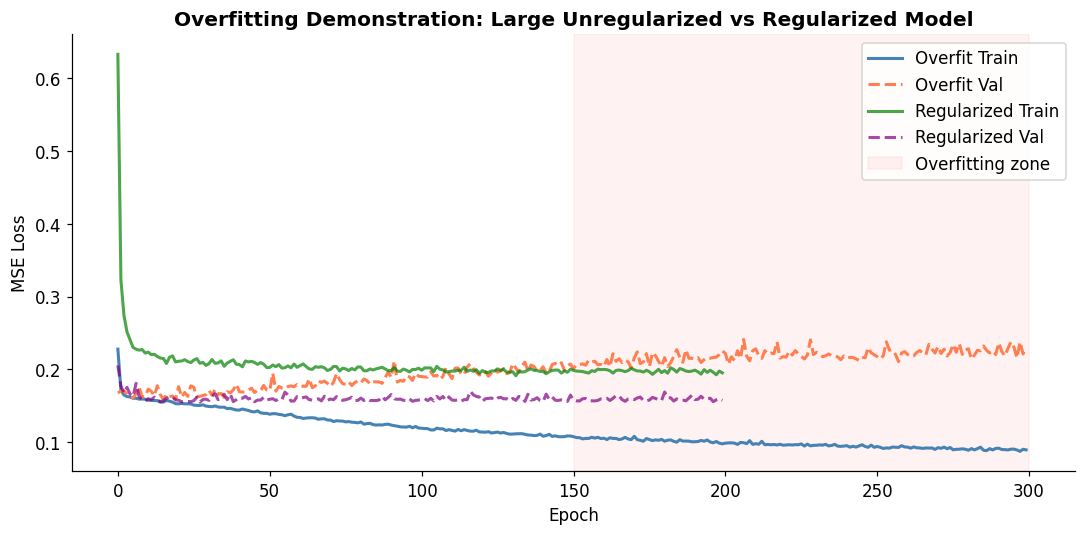


Overfit model  → Test R²: 0.7689, RMSE: 0.6063
Regularized    → Test R²: 0.8394, RMSE: 0.5054

Val-Train gap (last 20 epochs):
  Overfit    : +0.13611
  Regularized: -0.03777


In [115]:
###########################################
# Deliberately overfit: large model, no regularization
###########################################

torch.manual_seed(SEED)
model_overfit = MLPTorch(input_features, hidden_sizes=[256, 128, 64, 32])
opt_overfit   = optim.Adam(model_overfit.parameters(), lr=0.005)

tl_of, vl_of = train_pytorch(
    model_overfit, train_dataset_loader, X_va_t, y_va_t,
    optimizer=opt_overfit, epochs=300, verbose=False
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tl_of,   label='Overfit Train', color='steelblue',  linewidth=2)
ax.plot(vl_of,   label='Overfit Val',   color='coral',      linewidth=2, linestyle='--')
ax.plot(tl_best, label='Regularized Train', color='green',  linewidth=2, alpha=0.7)
ax.plot(vl_best, label='Regularized Val',   color='purple', linewidth=2, linestyle='--', alpha=0.7)

ax.axvspan(150, 300, alpha=0.05, color='red', label='Overfitting zone')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Overfitting Demonstration: Large Unregularized vs Regularized Model', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

m_of, _ = get_metrics_torch(model_overfit, X_te_t, y_test, y_mean, y_std)
m_re, _ = get_metrics_torch(model_combo, X_te_t, y_test, y_mean, y_std)

print(f"\nOverfit model  → Test R²: {m_of['r2']:.4f}, RMSE: {m_of['rmse']:.4f}")
print(f"Regularized    → Test R²: {m_re['r2']:.4f}, RMSE: {m_re['rmse']:.4f}")
print(f"\nVal-Train gap (last 20 epochs):")
print(f"  Overfit    : {np.mean(np.array(vl_of[-20:]) - np.array(tl_of[-20:])):+.5f}")
print(f"  Regularized: {np.mean(np.array(vl_best[-20:]) - np.array(tl_best[-20:])):+.5f}")

### B. Model Analaysis

In [66]:
###########################################
#  Comparing all models in a summary table
###########################################

results_df = pd.DataFrame(results_table).T.round(4)
results_df.index.name = 'Configuration'

# Add From Scratch results
results_df.loc['Model created using NumPy'] = {
    'rmse': basic_test['rmse'],
    'mae':  basic_test['mae'],
    'r2':   basic_test['r2'],
    'gap': np.mean(np.array(mlp_basic.val_losses[-20:]) - np.array(mlp_basic.train_losses[-20:]))
}

print("=" * 75)
print("Models Comparison Table  (Test Set — Battery Drop Prediction)")
print("=" * 75)
print(results_df.round(4).to_string())
print("\nBest model by R²    :", results_df['r2'].idxmax())
print("Best model by RMSE  :", results_df['rmse'].idxmin())
print("Best model by MAE   :", results_df['mae'].idxmin())
print("Most regularized gap:", results_df['gap'].idxmin())

Models Comparison Table  (Test Set — Battery Drop Prediction)
                             rmse     mae      r2     gap
Configuration                                            
Baseline                   0.5401  0.4350  0.8166  0.0566
L2 Reg                     0.5039  0.4072  0.8404  0.0055
L1 Reg                     0.5029  0.4053  0.8410  0.0004
Dropout                    0.5134  0.4141  0.8343 -0.0189
BatchNorm                  0.5112  0.4136  0.8357  0.0044
Best Combo                 0.5054  0.4072  0.8394 -0.0378
Model created using NumPy  0.3994  0.3220  0.8348  1.7451

Best model by R²    : L1 Reg
Best model by RMSE  : Model created using NumPy
Best model by MAE   : Model created using NumPy
Most regularized gap: Best Combo


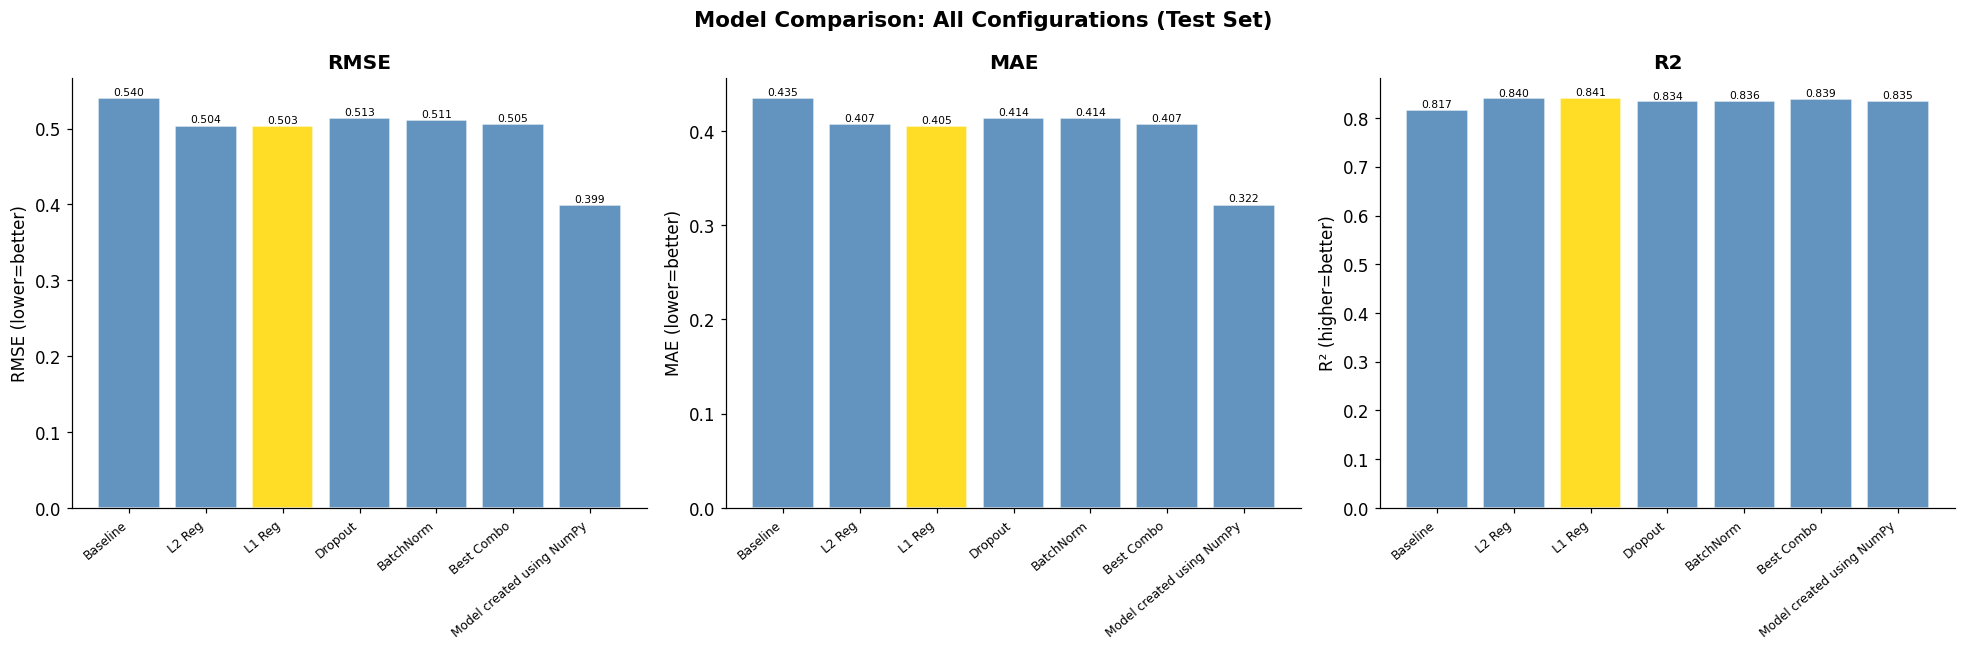

In [70]:
###########################################
#  Bar chart comparison
###########################################

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names  = list(results_df.index)
best_model = results_df['r2'].idxmax()
colors = ['steelblue' if n != best_model else 'gold' for n in names]

for ax, metric, ylabel in zip(
    axes,
    ['rmse', 'mae', 'r2'],
    ['RMSE (lower=better)', 'MAE (lower=better)', 'R² (higher=better)']
):
    vals = [results_df.loc[n, metric] for n in names]
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(metric.upper(), fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Comparison: All Configurations (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

## **Conclusion**

The following points highlight key insights from this assignment:
1. From scratch, MLP was implemented using NumPy and also later Pytorch was used for creating an advance MLP where regularizationa and optimizer was easily implemented. 
2. Concepts like regularization, dropout, L1, L2, Adam, SDG, EDA, SHAP, Pearson Correlation were in depth explored.
3. Multiple experiements done, compared and analyized.